In [1]:
import sleap
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import sys
sys.path.append('..')
from python.animation import *
from python.postprocess import *
from eval import *
sleap.versions()
sleap.system_summary()

SLEAP: 1.4.1
TensorFlow: 2.7.0
Numpy: 1.21.5
Python: 3.7.12
OS: Linux-6.8.0-51-generic-x86_64-with-debian-trixie-sid
GPUs: 2/2 available
  Device: /physical_device:GPU:0
         Available: True
       Initialized: False
     Memory growth: None
  Device: /physical_device:GPU:1
         Available: True
       Initialized: False
     Memory growth: None


Labels(labeled_frames=45000, videos=1, skeletons=1, tracks=17)
all_tracked_points shape: (45000, 17, 2)
First non missing frame idx: 0
Missing point count: 72608
reorder_idx.shape: (17,)
total_range_length: 4844


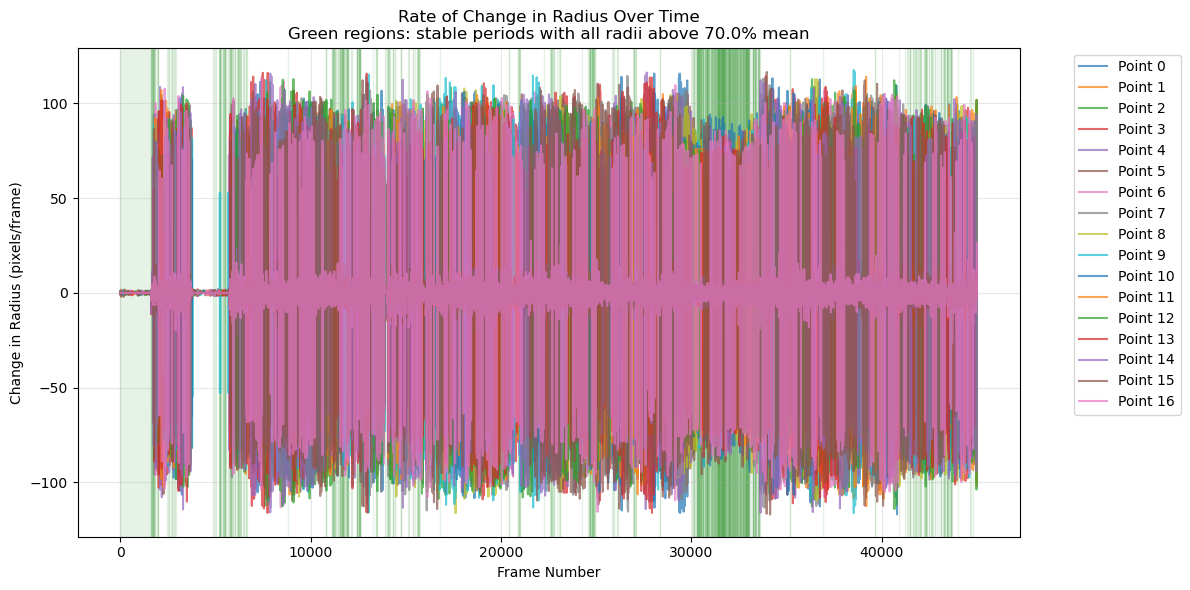

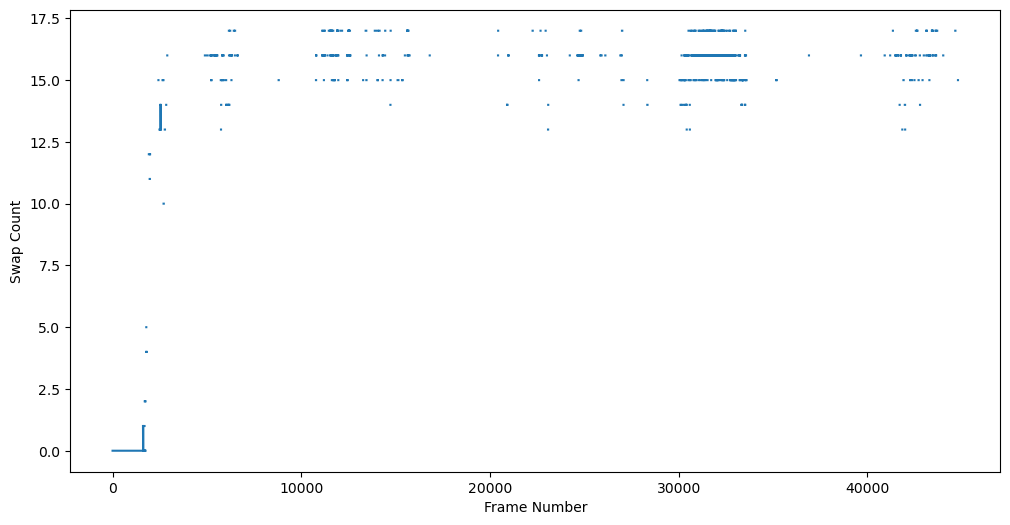

In [2]:
dataset_path = '/home/mingxiao/Desktop/jellyfish/video/video_1_clips/reencoded_5min_v2.slp'
eval_dataset(dataset_path)

Labels(labeled_frames=9000, videos=1, skeletons=1, tracks=17)
all_tracked_points shape: (9000, 17, 2)
First non missing frame idx: 0
Missing point count: 7440
reorder_idx.shape: (17,)
total_range_length: 3721


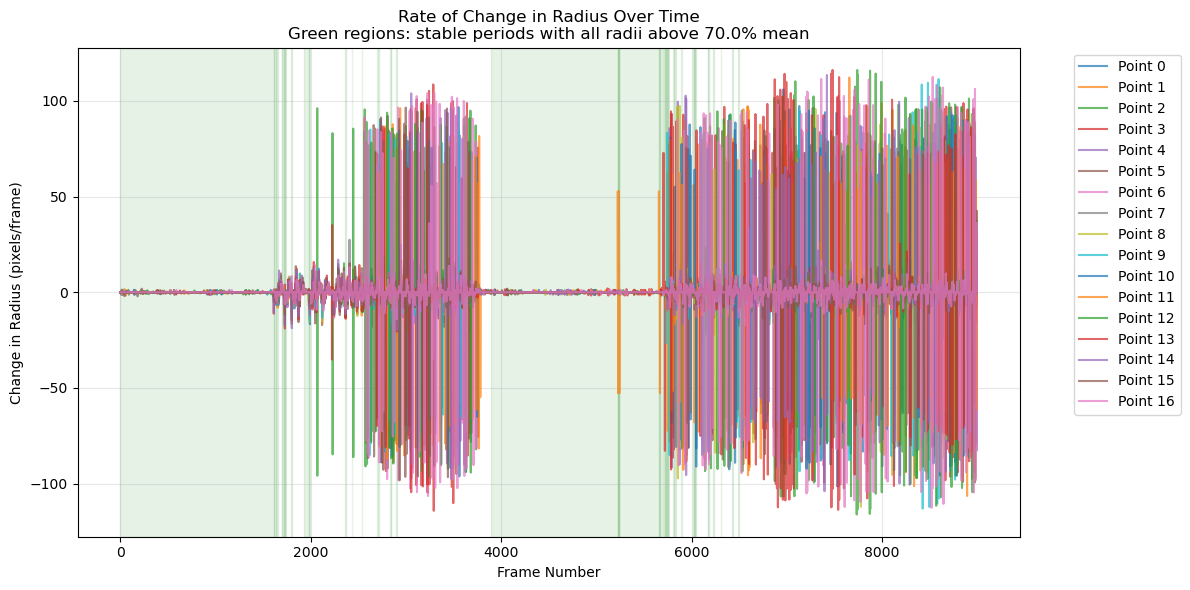

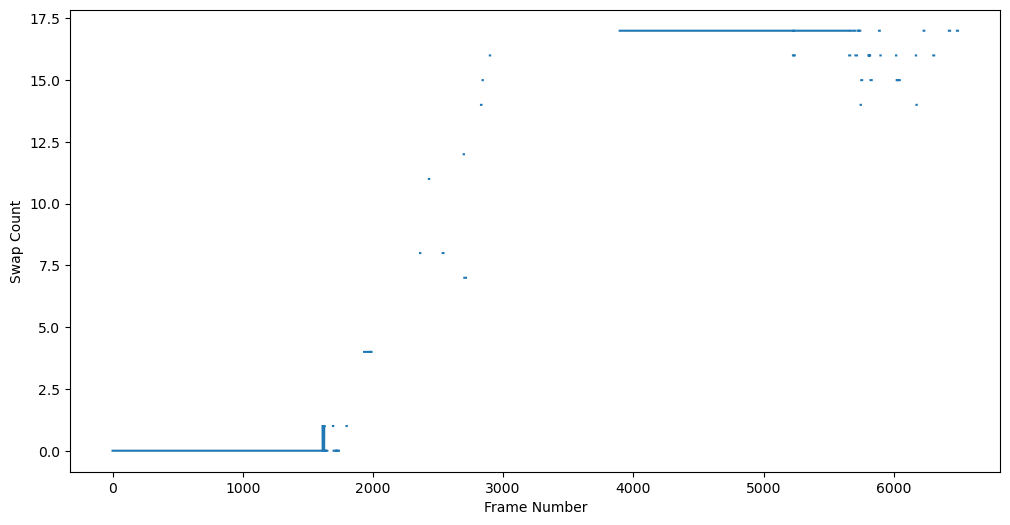

In [3]:
corrected_dataset_path = '/home/mingxiao/Desktop/jellyfish/video/video_1_clips/manual_5min_c0.slp'
eval_dataset(corrected_dataset_path)

Labels(labeled_frames=9000, videos=1, skeletons=1, tracks=17)
all_tracked_points shape: (9000, 17, 2)
First non missing frame idx: 0
Missing point count: 7440
reorder_idx.shape: (17,)
total_range_length: 3721


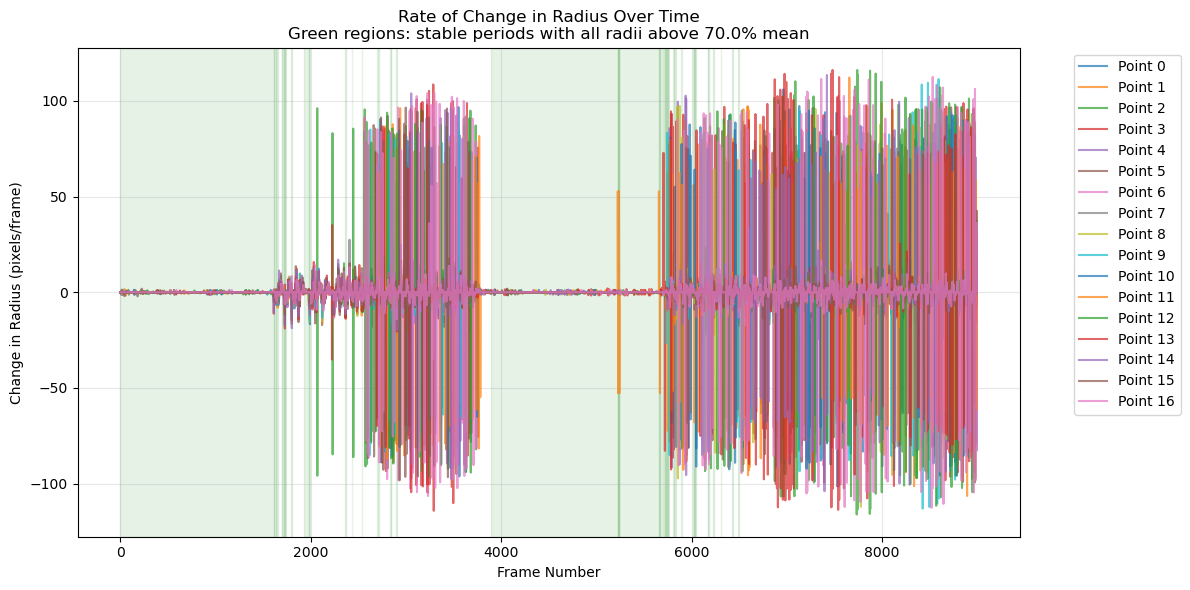

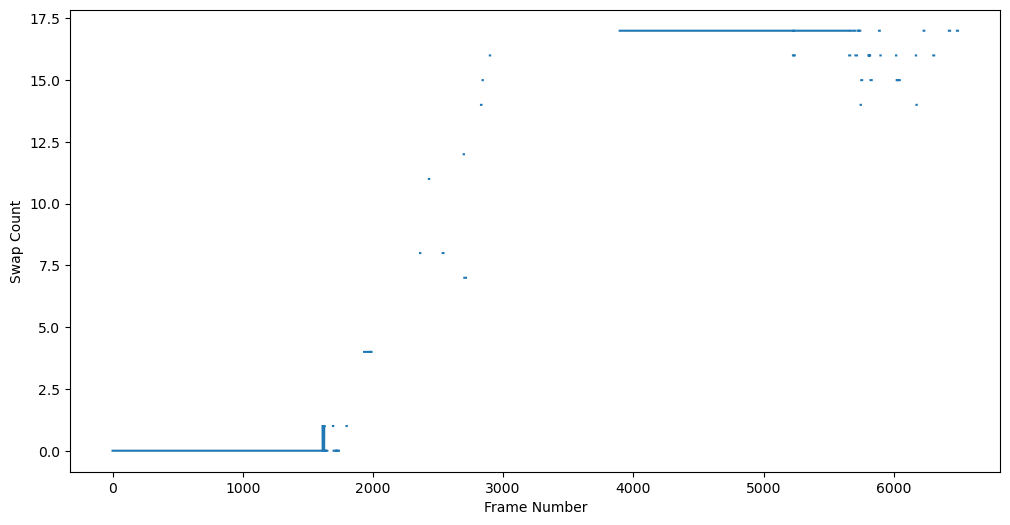

In [4]:
c0_dataset_path = '/home/mingxiao/Desktop/jellyfish/video/video_1_clips/v2_c0_training.slp'
eval_dataset(c0_dataset_path)

In [ ]:
c0_dataset = sleap.load_file(c0_dataset_path)
c0_tracked_points = get_all_tracked_points(c0_dataset, reorder=True, interpolate=False, min_score=0, start_idx=0)

all_tracked_points shape: (9000, 17, 2)
First non missing frame idx: 0
Missing point count: 7440
reorder_idx.shape: (17,)


In [4]:
c0_radii = get_all_radii(c0_tracked_points)

mean_radii: [35.42906538 37.04652507 30.33596578 31.95876995 30.45473787 31.37992018
 31.66517385 32.61990258 34.74045555 35.89509068 37.99634593 38.84475223
 31.28955836 30.44321882 36.86881502 34.43657126 31.80388805]
total_range_length: 3697
Stable ranges (frame numbers) with minimum length of 1 frames and all radii above 70.0% mean:
    - Frames 0 to 42 (length: 42)
    - Frames 44 to 180 (length: 136)
    - Frames 182 to 1611 (length: 1429)
    - Frames 1613 to 1630 (length: 17)
    - Frames 1632 to 1635 (length: 3)
    - Frames 1637 to 1640 (length: 3)
    - Frames 1642 to 1646 (length: 4)
    - Frames 1648 to 1651 (length: 3)
    - Frames 1693 to 1696 (length: 3)
    - Frames 1698 to 1701 (length: 3)
    - Frames 1703 to 1716 (length: 13)
    - Frames 1718 to 1727 (length: 9)
    - Frames 1730 to 1740 (length: 10)
    - Frames 1797 to 1800 (length: 3)
    - Frames 1932 to 1980 (length: 48)
    - Frames 1982 to 1990 (length: 8)
    - Frames 2362 to 2365 (length: 3)
    - Frames 2

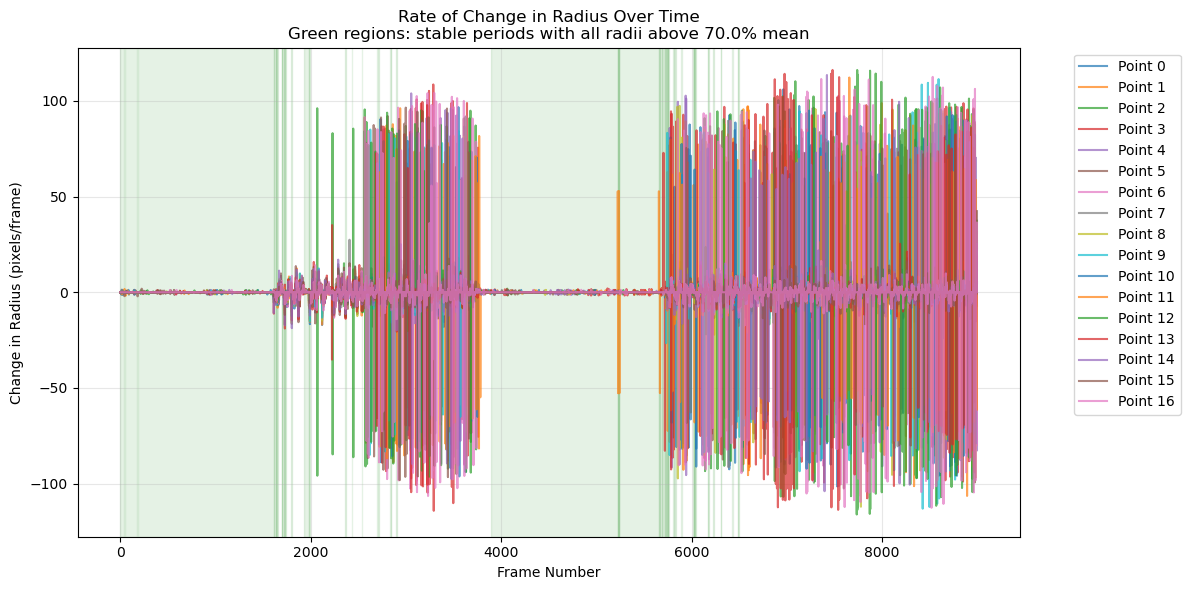

In [5]:
c0_filtered_ranges = get_expanded_periods(c0_radii, min_range_length=1, mean_scale=0.7, derivative_thres=2, plot=True)

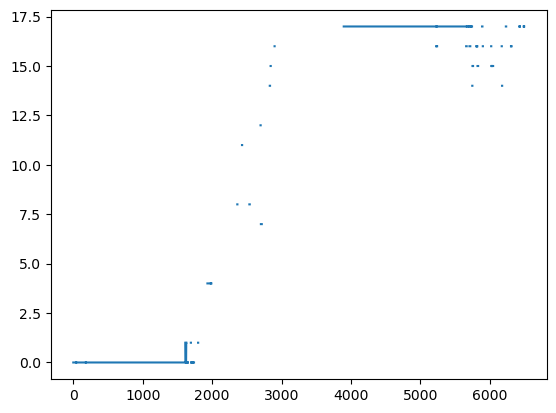

In [19]:
swap_cnt_lst = []
for i in range(c0_tracked_points.shape[0]):
    swap_cnt_lst.append(get_swap_count(c0_tracked_points[i], count_missing=False))
    
swap_cnt_lst_masked = mask_missing_points(c0_filtered_ranges, swap_cnt_lst)

plt.plot(swap_cnt_lst_masked)
plt.show()